# Mini-Projeto: Visão Computacional e Machine Learning na Indústria 4.0
### Inspeção de Qualidade Automatizada em Peças de Fundição Metálica (*Casting Product Dataset*)

---

## Sumário Executivo do Projeto
- **Contexto Industrial:** Automação da inspeção de qualidade em esteiras industriais na Indústria 4.0.
- **Abordagem Híbrida:** 
  1. **Visão Computacional Clássica (OpenCV):** Análise exploratória, remoção de ruídos, limiarização, detecção de bordas estruturais e operações morfológicas para isolamento de trincas, rebarbas e porosidades.
  2. **Deep Learning (TensorFlow/Keras):** Ingestão em lote, *Data Augmentation* dinâmico para simulação de variações de esteira e Rede Neural Convolucional (CNN) Sequencial para classificação automatizada em larga escala (*Aprovada / Defeituosa*).
- **Estrutura:** Dividido em 6 Sprints Industriais de desenvolvimento e auditoria.


---
# Sprint 1: Configuração do Ambiente e Ingestão Inicial do Dataset
Nesta etapa, importamos as bibliotecas fundamentais, configuramos as sementes de aleatoriedade para garantir reprodutibilidade e verificamos a estrutura do dataset de fundição.


In [1]:
import os
import sys
import glob
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Garantir que o diretório de trabalho seja a raiz do projeto
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

# Reprodutibilidade
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATASET_DIR = 'dataset/casting_512x512'
def_dir = os.path.join(DATASET_DIR, 'def_front')
ok_dir = os.path.join(DATASET_DIR, 'ok_front')

print(f'TensorFlow Version: {tf.__version__}')
print(f'OpenCV Version: {cv2.__version__}')
print(f'Total de Peças Defeituosas (def_front): {len(os.listdir(def_dir))}')
print(f'Total de Peças Aprovadas (ok_front): {len(os.listdir(ok_dir))}')


I0000 00:00:1788908111.323244    7331 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788908111.384542    7331 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788908112.935541    7331 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0
OpenCV Version: 5.0.0
Total de Peças Defeituosas (def_front): 781
Total de Peças Aprovadas (ok_front): 519


---
# Sprint 2: Análise Exploratória Clássica com OpenCV
Extraímos amostras de peças com e sem defeito e aplicamos transformações fundamentais:
1. Conversão para **Escala de Cinza** (*Grayscale*) para reduzir a dimensionalidade e focar na intensidade luminosa.
2. Suavização de ruídos industriais: Comparativo entre **Filtro Gaussiano** (*Gaussian Blur*) e **Filtro de Mediana** (*Median Blur*).


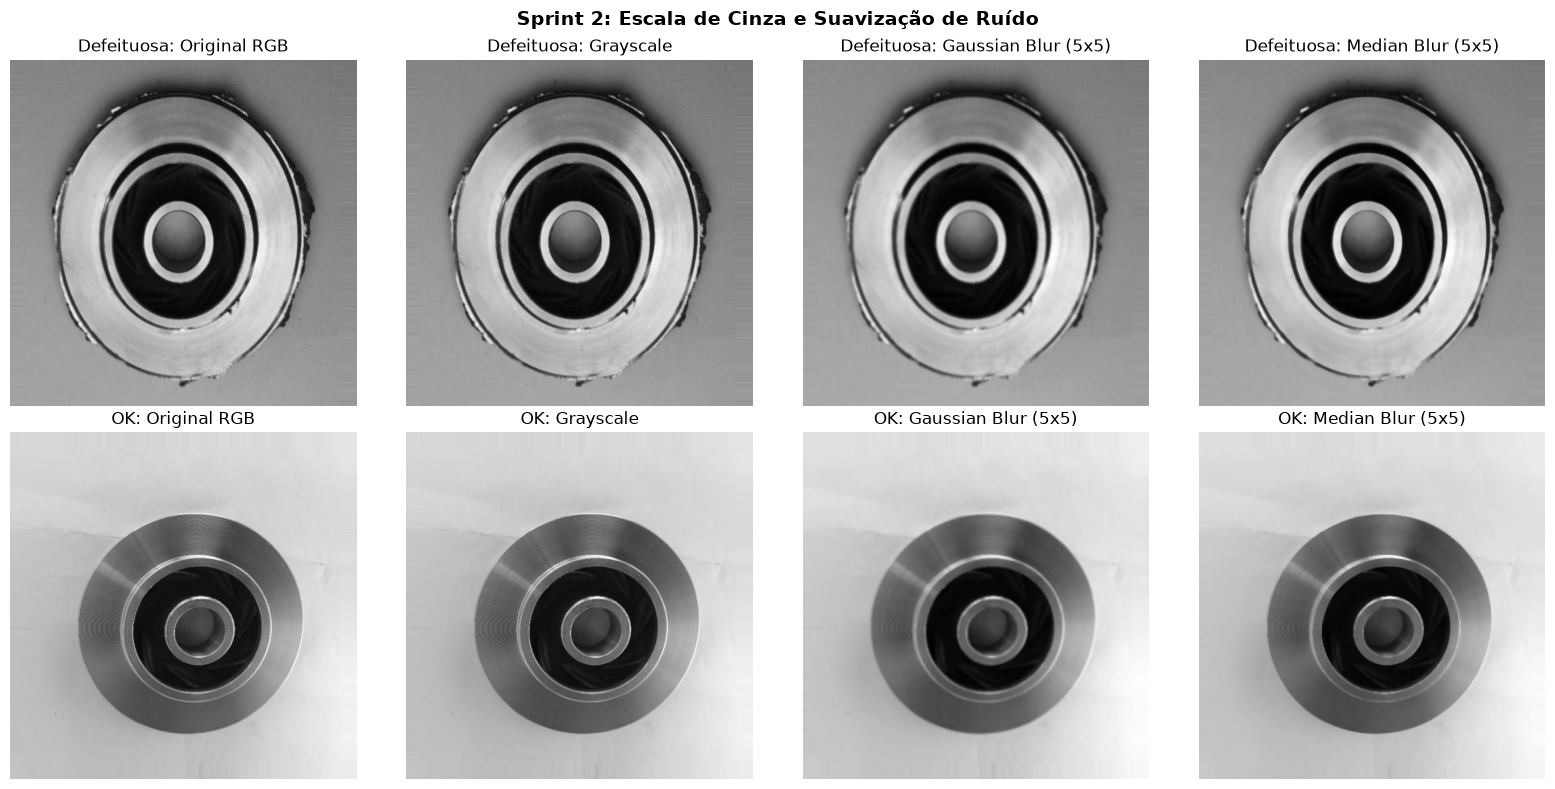

In [2]:
from src.classical_vision import convert_to_grayscale, apply_blur_filters

sample_def_path = 'dataset/casting_512x512/def_front/cast_def_0_0.jpeg'
sample_ok_path = 'dataset/casting_512x512/ok_front/cast_ok_0_1018.jpeg'

img_def_bgr = cv2.imread(sample_def_path)
img_ok_bgr = cv2.imread(sample_ok_path)

gray_def = convert_to_grayscale(img_def_bgr)
gray_ok = convert_to_grayscale(img_ok_bgr)

blur_def = apply_blur_filters(gray_def, kernel_size=5)
blur_ok = apply_blur_filters(gray_ok, kernel_size=5)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sprint 2: Escala de Cinza e Suavização de Ruído', fontsize=14, fontweight='bold')

# Peça Defeituosa
axes[0, 0].imshow(cv2.cvtColor(img_def_bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Defeituosa: Original RGB')
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_def, cmap='gray')
axes[0, 1].set_title('Defeituosa: Grayscale')
axes[0, 1].axis('off')

axes[0, 2].imshow(blur_def['gaussian'], cmap='gray')
axes[0, 2].set_title('Defeituosa: Gaussian Blur (5x5)')
axes[0, 2].axis('off')

axes[0, 3].imshow(blur_def['median'], cmap='gray')
axes[0, 3].set_title('Defeituosa: Median Blur (5x5)')
axes[0, 3].axis('off')

# Peça OK
axes[1, 0].imshow(cv2.cvtColor(img_ok_bgr, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('OK: Original RGB')
axes[1, 0].axis('off')

axes[1, 1].imshow(gray_ok, cmap='gray')
axes[1, 1].set_title('OK: Grayscale')
axes[1, 1].axis('off')

axes[1, 2].imshow(blur_ok['gaussian'], cmap='gray')
axes[1, 2].set_title('OK: Gaussian Blur (5x5)')
axes[1, 2].axis('off')

axes[1, 3].imshow(blur_ok['median'], cmap='gray')
axes[1, 3].set_title('OK: Median Blur (5x5)')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


---
# Sprint 3: Destaque de Características e Morfologia Matemática
Nesta etapa, aplicamos técnicas avançadas de processamento clássico:
- **Limiarização de Otsu:** Segmentação binarizada automática de alto contraste.
- **Detecção de Bordas (Canny e Sobel):** Realce de gradientes abruptos que indicam trincas, rebarbas e fissuras estruturais.
- **Morfologia Matemática (Dilatação e Fechamento):** Conexão de microfraturas e eliminação de pequenos ruídos residuais.
- **Segmentação e Isolamento Visual:** Destaque dos defeitos detectados sobre a peça original.


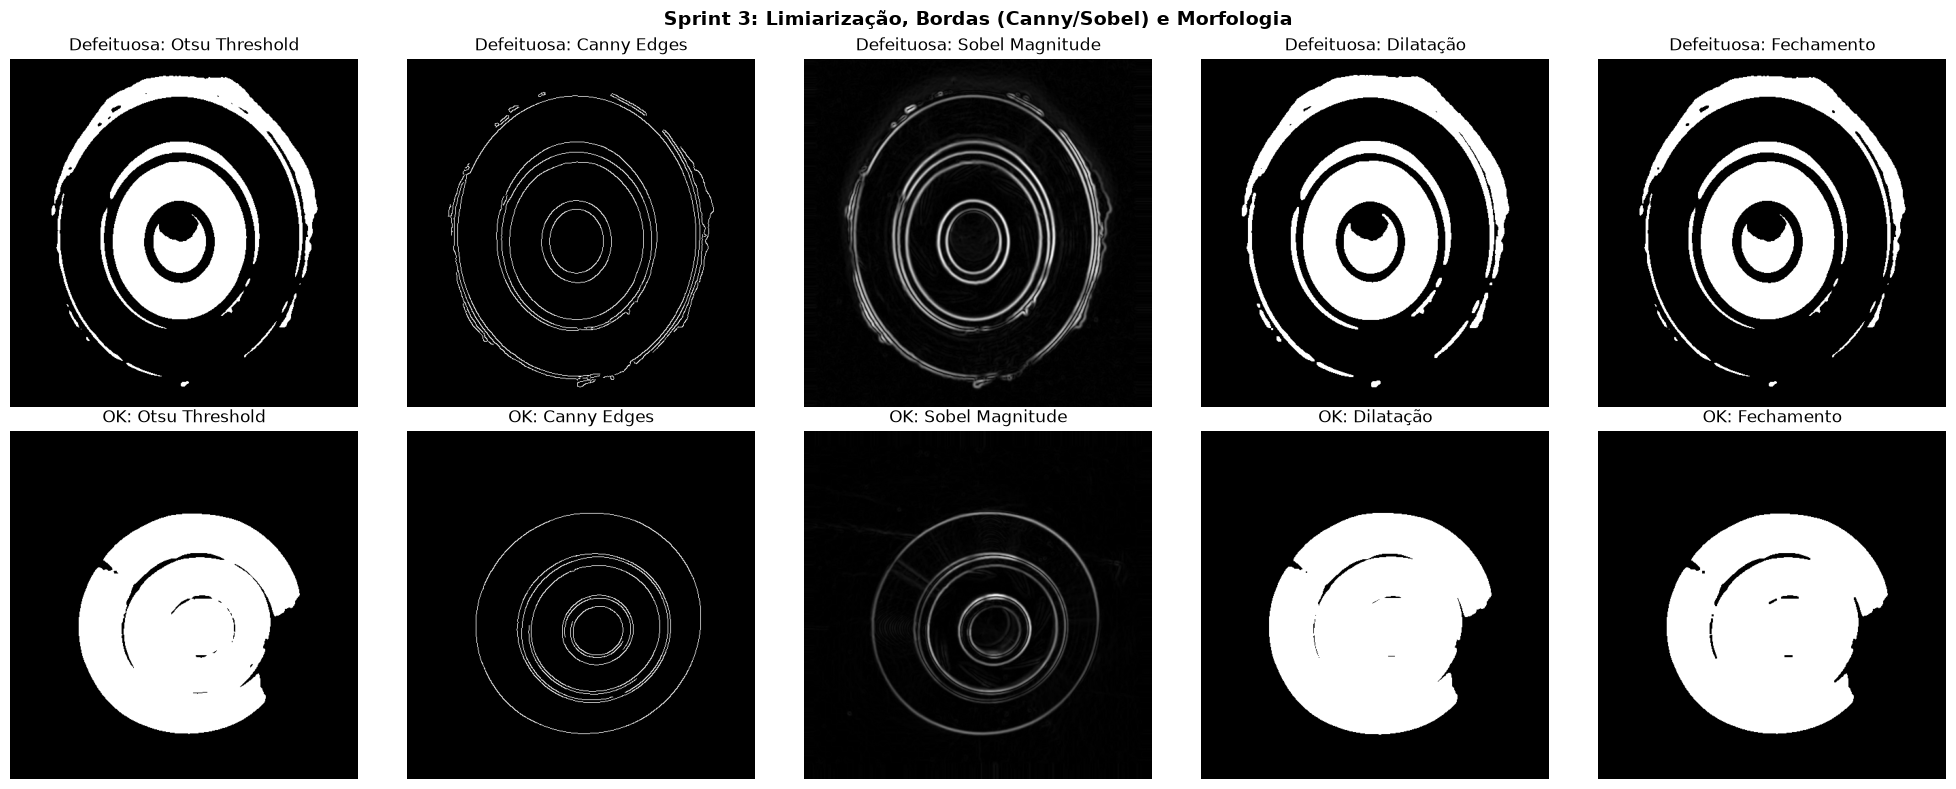

In [3]:
from src.classical_vision import apply_edge_detection, apply_thresholding, apply_morphological_ops, isolate_and_highlight_defects

edge_def = apply_edge_detection(blur_def['gaussian'])
edge_ok = apply_edge_detection(blur_ok['gaussian'])

thresh_def = apply_thresholding(blur_def['gaussian'])
thresh_ok = apply_thresholding(blur_ok['gaussian'])

morph_def = apply_morphological_ops(thresh_def['otsu'], kernel_size=3)
morph_ok = apply_morphological_ops(thresh_ok['otsu'], kernel_size=3)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sprint 3: Limiarização, Bordas (Canny/Sobel) e Morfologia', fontsize=14, fontweight='bold')

# Peça Defeituosa
axes[0, 0].imshow(thresh_def['otsu'], cmap='gray')
axes[0, 0].set_title('Defeituosa: Otsu Threshold')
axes[0, 0].axis('off')

axes[0, 1].imshow(edge_def['canny'], cmap='gray')
axes[0, 1].set_title('Defeituosa: Canny Edges')
axes[0, 1].axis('off')

axes[0, 2].imshow(edge_def['sobel'], cmap='gray')
axes[0, 2].set_title('Defeituosa: Sobel Magnitude')
axes[0, 2].axis('off')

axes[0, 3].imshow(morph_def['dilation'], cmap='gray')
axes[0, 3].set_title('Defeituosa: Dilatação')
axes[0, 3].axis('off')

axes[0, 4].imshow(morph_def['closing'], cmap='gray')
axes[0, 4].set_title('Defeituosa: Fechamento')
axes[0, 4].axis('off')

# Peça OK
axes[1, 0].imshow(thresh_ok['otsu'], cmap='gray')
axes[1, 0].set_title('OK: Otsu Threshold')
axes[1, 0].axis('off')

axes[1, 1].imshow(edge_ok['canny'], cmap='gray')
axes[1, 1].set_title('OK: Canny Edges')
axes[1, 1].axis('off')

axes[1, 2].imshow(edge_ok['sobel'], cmap='gray')
axes[1, 2].set_title('OK: Sobel Magnitude')
axes[1, 2].axis('off')

axes[1, 3].imshow(morph_ok['dilation'], cmap='gray')
axes[1, 3].set_title('OK: Dilatação')
axes[1, 3].axis('off')

axes[1, 4].imshow(morph_ok['closing'], cmap='gray')
axes[1, 4].set_title('OK: Fechamento')
axes[1, 4].axis('off')

plt.tight_layout()
plt.show()


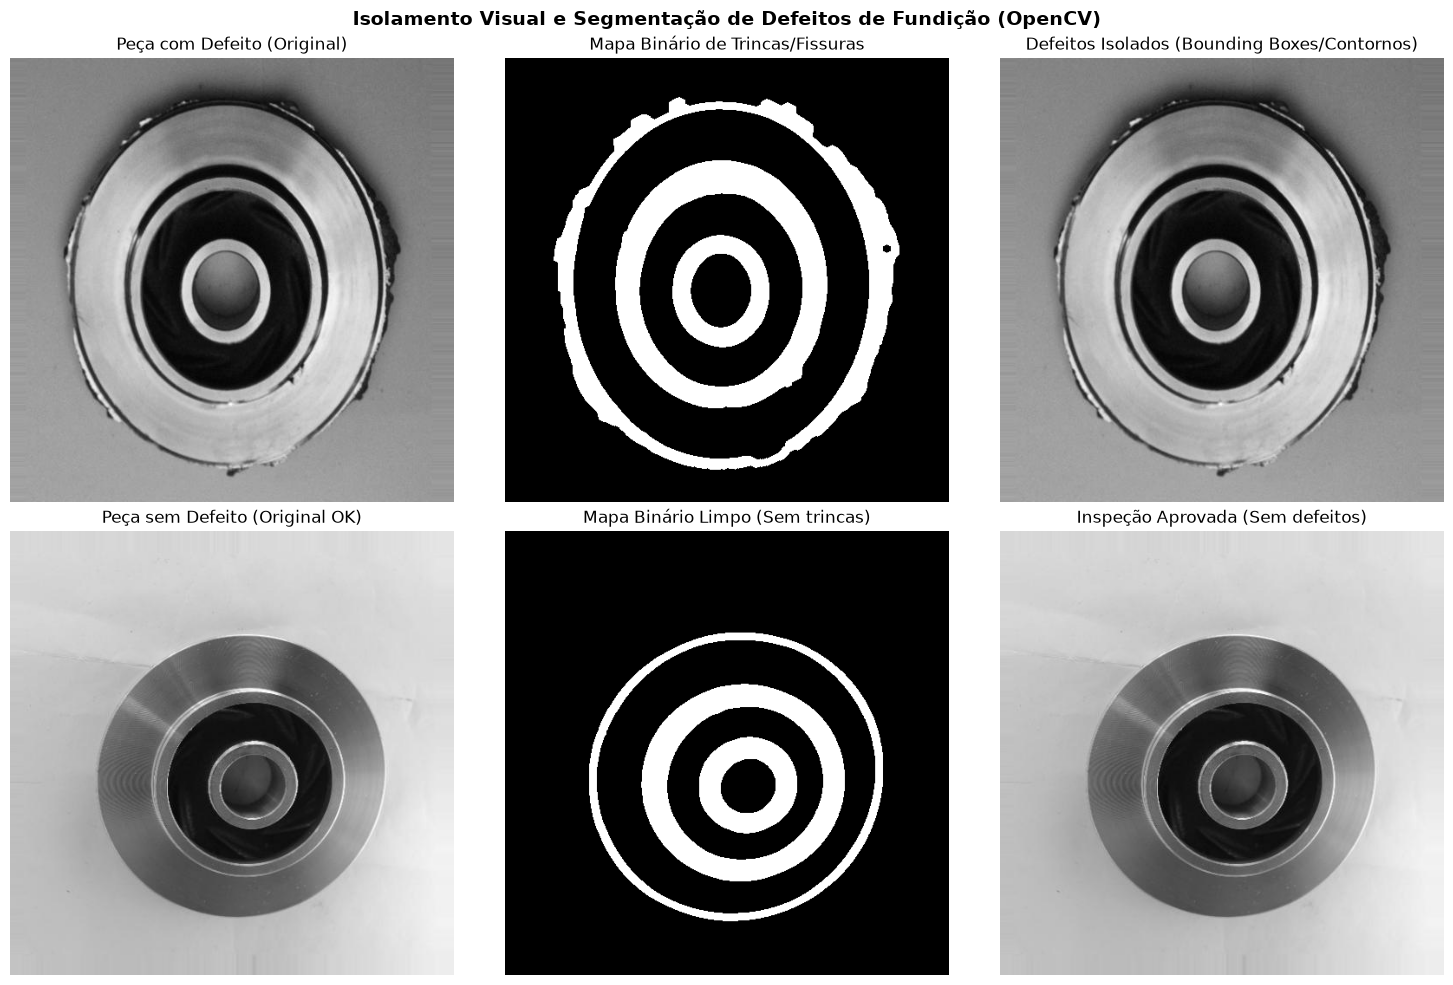

In [4]:
# Comparativo de Isolamento Final de Defeitos
iso_def = isolate_and_highlight_defects(img_def_bgr)
iso_ok = isolate_and_highlight_defects(img_ok_bgr)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Isolamento Visual e Segmentação de Defeitos de Fundição (OpenCV)', fontsize=14, fontweight='bold')

# Defeituosa
axes[0, 0].imshow(cv2.cvtColor(img_def_bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Peça com Defeito (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(iso_def['closed_edges'], cmap='gray')
axes[0, 1].set_title('Mapa Binário de Trincas/Fissuras')
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.cvtColor(iso_def['highlighted'], cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('Defeitos Isolados (Bounding Boxes/Contornos)')
axes[0, 2].axis('off')

# OK
axes[1, 0].imshow(cv2.cvtColor(img_ok_bgr, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Peça sem Defeito (Original OK)')
axes[1, 0].axis('off')

axes[1, 1].imshow(iso_ok['closed_edges'], cmap='gray')
axes[1, 1].set_title('Mapa Binário Limpo (Sem trincas)')
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.cvtColor(iso_ok['highlighted'], cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Inspeção Aprovada (Sem defeitos)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


---
# Sprint 4: Ingestão em Lote e Data Augmentation Dinâmico (Keras)
Carregamos os dados em lotes com `image_dataset_from_directory` (divisão 80% Treino e 20% Validação).
Para imunizar o modelo contra oscilações de posição, orientação e iluminação na esteira transportadora, implementamos uma camada de **Data Augmentation dinâmico**:
- Rotações aleatórias (`RandomRotation`)
- Espelhamentos horizontal e vertical (`RandomFlip`)
- Variações de escala e zoom (`RandomZoom`)
- Variações de iluminação e contraste (`RandomBrightness`, `RandomContrast`)


Found 1300 files belonging to 2 classes.


Using 1040 files for training.


Found 1300 files belonging to 2 classes.


Using 260 files for validation.


Classes identificadas: ['def_front', 'ok_front'] (0: def_front, 1: ok_front)


E0000 00:00:1788908116.541914    7331 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1788908116.730939    7425 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.
W0000 00:00:1788908116.747964    7424 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.


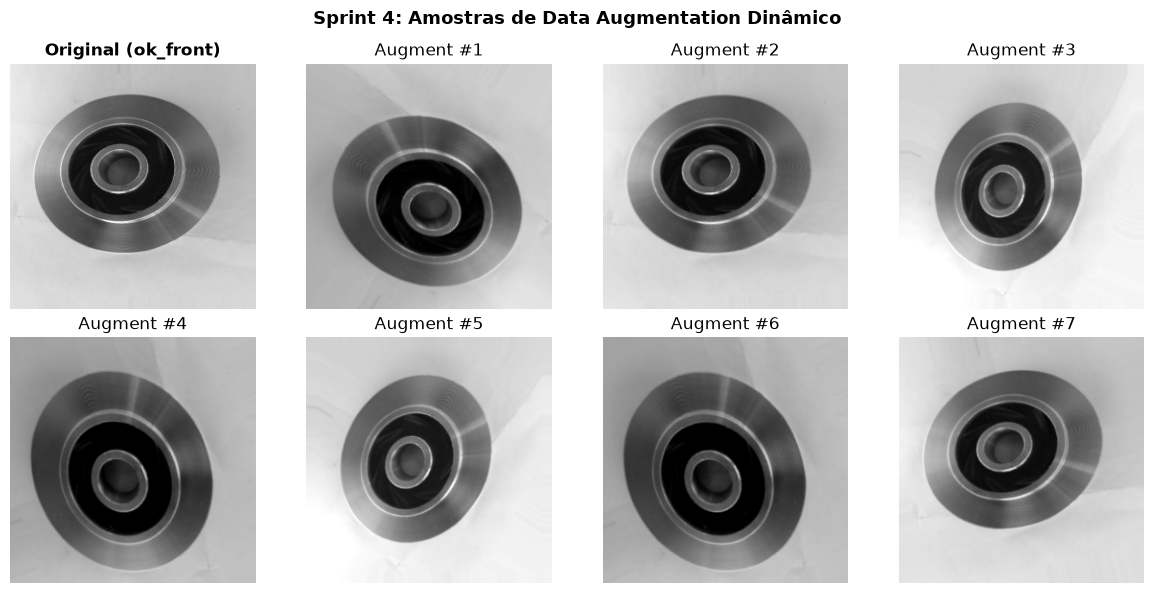

In [5]:
from src.model_pipeline import load_datasets, get_data_augmentation_pipeline

train_ds, val_ds, class_names, raw_train_ds, raw_val_ds = load_datasets()
aug_pipeline = get_data_augmentation_pipeline()

# Visualização do Data Augmentation
for images, labels in raw_train_ds.take(1):
    sample_img = images[0]
    sample_label = class_names[int(labels[0].numpy().item())]

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 4, 1)
    plt.imshow(sample_img.numpy().astype('uint8'))
    plt.title(f'Original ({sample_label})', fontweight='bold')
    plt.axis('off')

    for i in range(7):
        augmented = aug_pipeline(tf.expand_dims(sample_img, 0), training=True)
        plt.subplot(2, 4, i + 2)
        plt.imshow(augmented[0].numpy().astype('uint8'))
        plt.title(f'Augment #{i+1}')
        plt.axis('off')

    plt.suptitle('Sprint 4: Amostras de Data Augmentation Dinâmico', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    break


---
# Sprint 5: Arquitetura da Rede Neural Convolucional (CNN) e Treinamento
Construímos um modelo Sequencial estruturado com:
- Camada de **Normalização** (`Rescaling(1./255)`).
- 4 Blocos Convolucionais intercalados de **Extração de Características** (`Conv2D` + `MaxPooling2D`).
- Camada de Regularização **Dropout** para prevenir overfitting.
- Achatamento matricial (`Flatten`).
- Camada **Densa** intermediária (`Dense(64, relu)`).
- Camada de **Decisão Binária** com ativação Sigmoid (`Dense(1, sigmoid)`).
- Compilação com o otimizador **Adam** e função de perda **Binary Crossentropy**.


In [6]:
from src.model_pipeline import build_cnn_model, train_model

model = build_cnn_model(input_shape=(256, 256, 3))
model.summary()


Model: "Industrial_Casting_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_norm (Rescaling)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block1 (Conv2D)          │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block1 (MaxPooling2D)   │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block2 (Conv2D)          │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block2 (MaxPooling2D)   │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block3 (Conv2D)          │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block3 (MaxPooling2D)   │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block4 (Conv2D)          │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block4 (MaxPooling2D)   │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_features (Dropout)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_transition (Flatten)    │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338,113 (8.92 MB)

 Trainable params: 2,338,113 (8.92 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Carregamento do melhor modelo treinado
best_model_path = 'models/casting_cnn_model.keras'
if os.path.exists(best_model_path):
    print('Carregando modelo treinado salvo em:', best_model_path)
    trained_model = tf.keras.models.load_model(best_model_path)
else:
    history, best_model_path = train_model(model, train_ds, val_ds, epochs=15)
    trained_model = tf.keras.models.load_model(best_model_path)


Carregando modelo treinado salvo em: models/casting_cnn_model.keras


---
# Sprint 6: Auditoria Gráfica, Avaliação e Diagnóstico de Overfitting
Auditamos o desempenho do modelo na base de validação independente:
1. **Curvas de Perda (Loss e Val_Loss):** Avaliação de convergência e ausência de overfitting.
2. **Curvas de Acurácia (Train vs Val):** Estabilidade de generalização.
3. **Matriz de Confusão e Relatório de Classificação:** Precisão, Recall e F1-Score por classe industrial.


In [8]:
from src.model_pipeline import evaluate_and_generate_metrics

report = evaluate_and_generate_metrics(trained_model, raw_val_ds, class_names)


W0000 00:00:1788908118.091319    7447 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.
W0000 00:00:1788908118.106816    7446 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.
W0000 00:00:1788908118.127686    7443 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.


Salva Matriz de Confusão em: reports/figures/sprint6_confusion_matrix.png

--- Relatório de Classificação Final ---
              precision    recall  f1-score   support

   def_front       0.97      0.80      0.88       149
    ok_front       0.78      0.96      0.86       111

    accuracy                           0.87       260
   macro avg       0.87      0.88      0.87       260
weighted avg       0.89      0.87      0.87       260



Salvas predições de amostra em: reports/figures/sprint6_sample_predictions.png


--- Curvas Analíticas de Treinamento ---


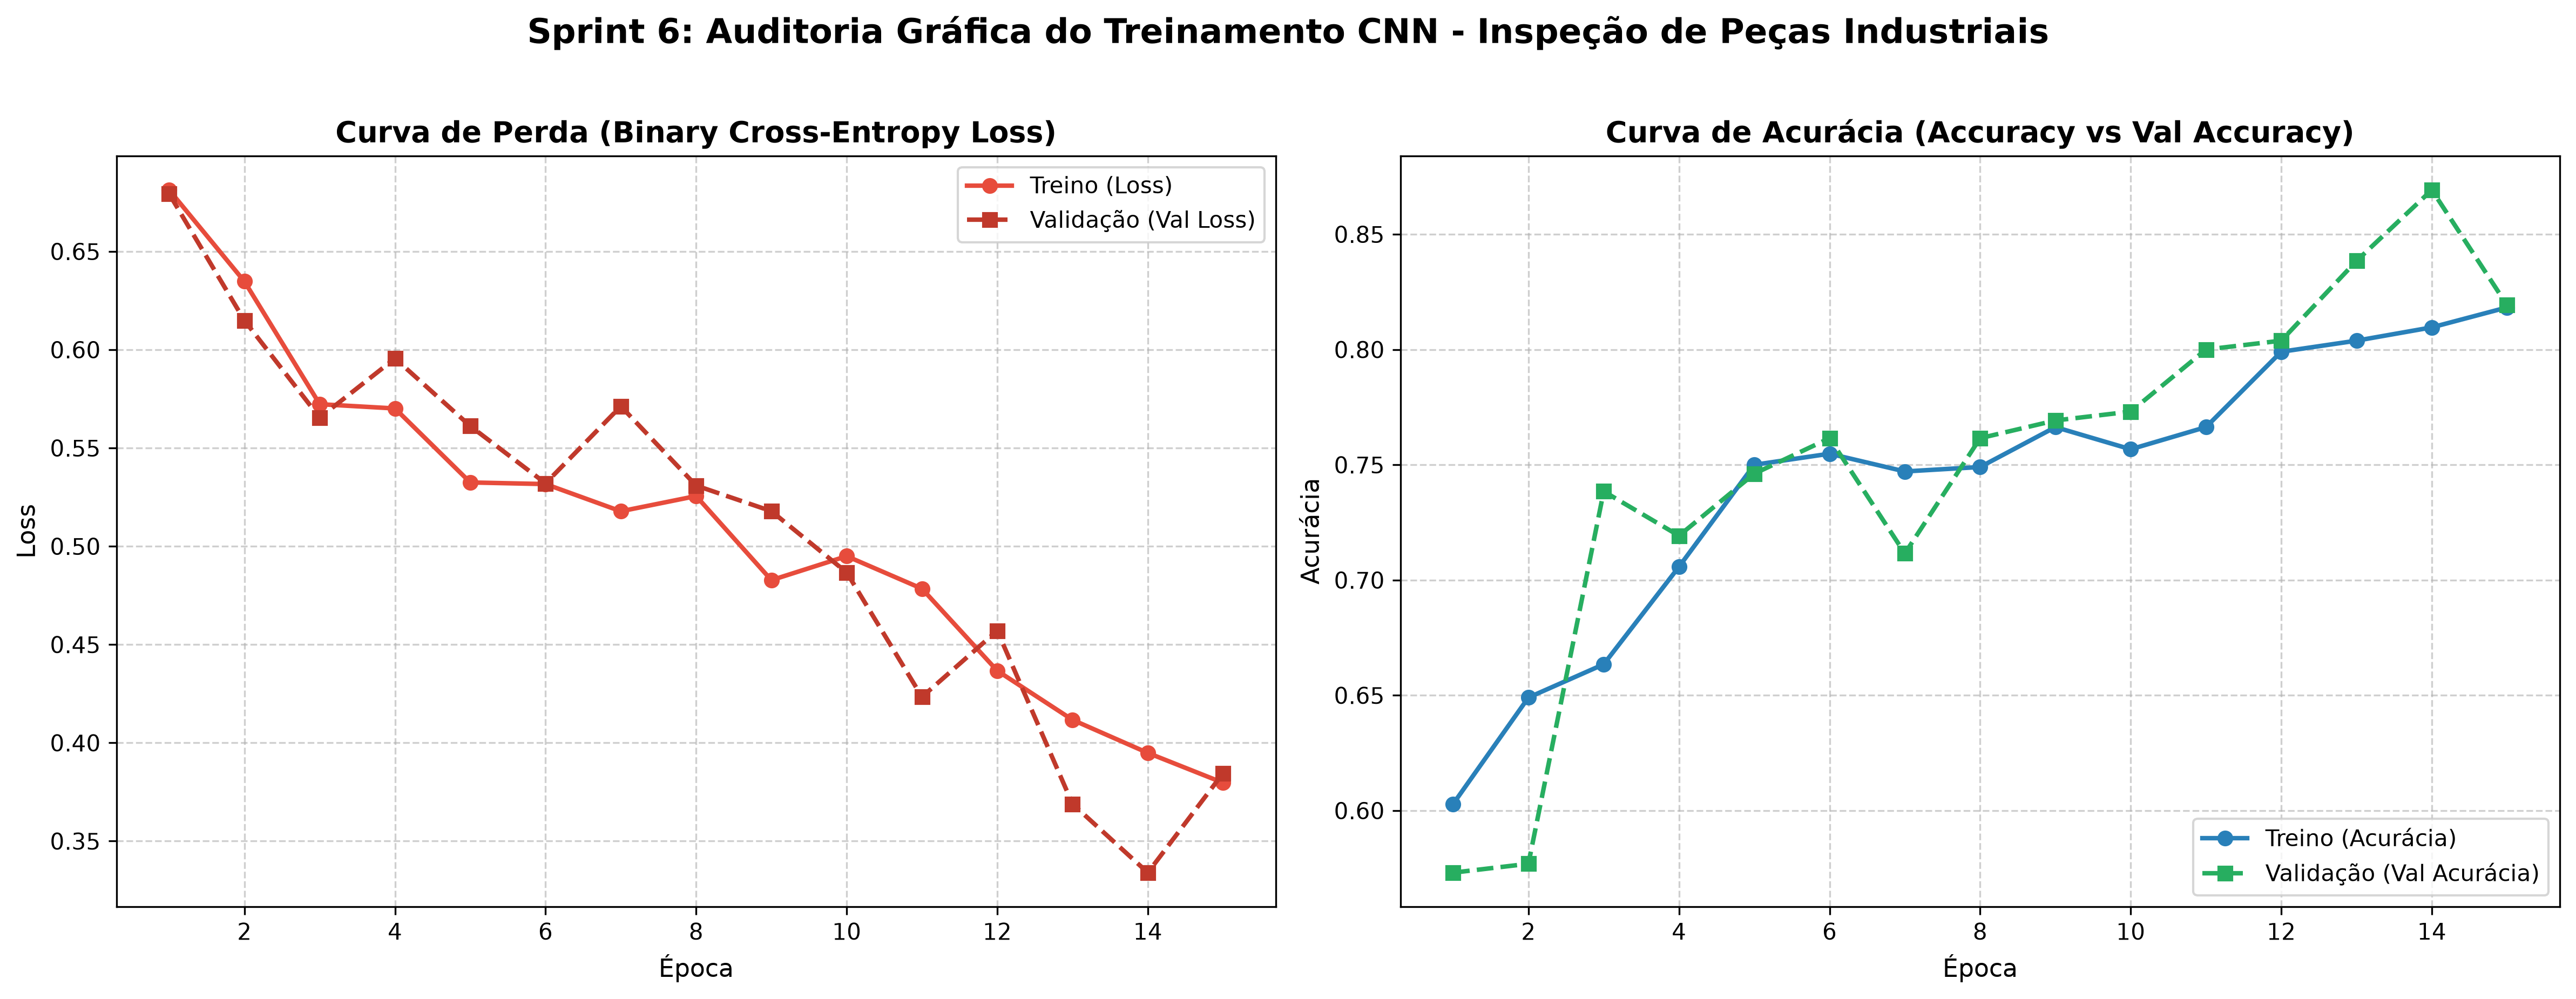

--- Matriz de Confusão na Validação ---


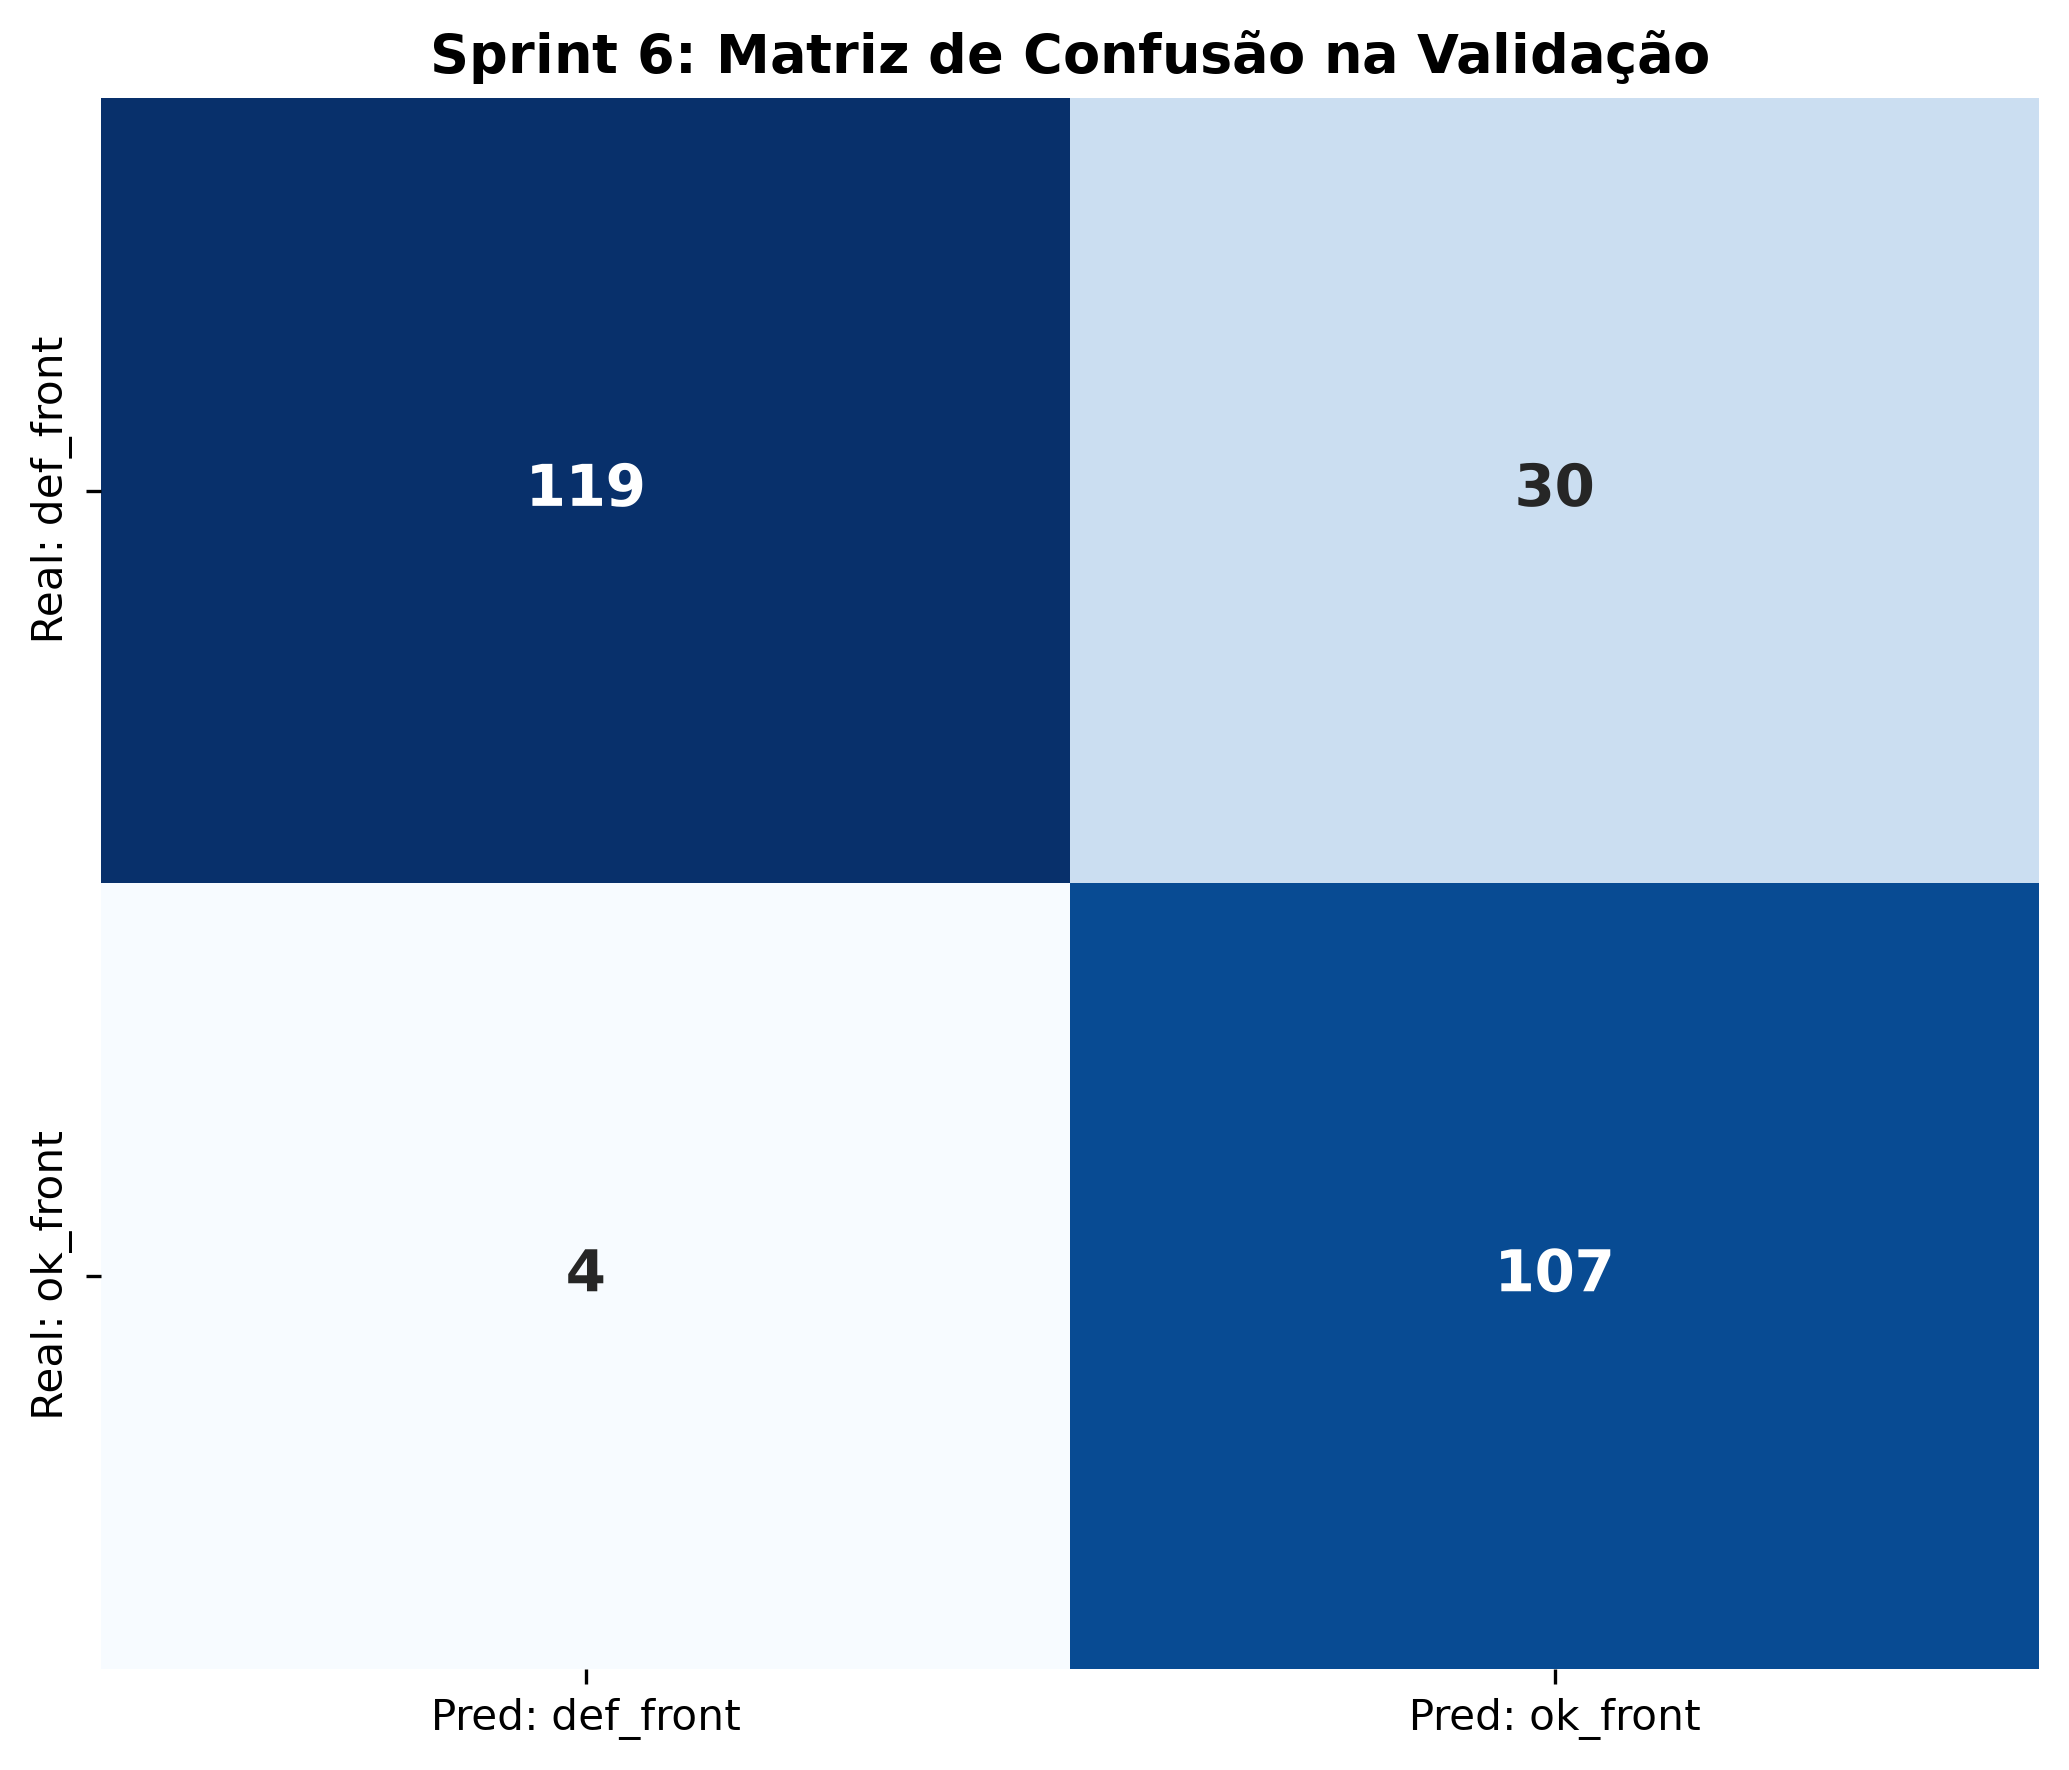

--- Amostras de Predição Industrial ---


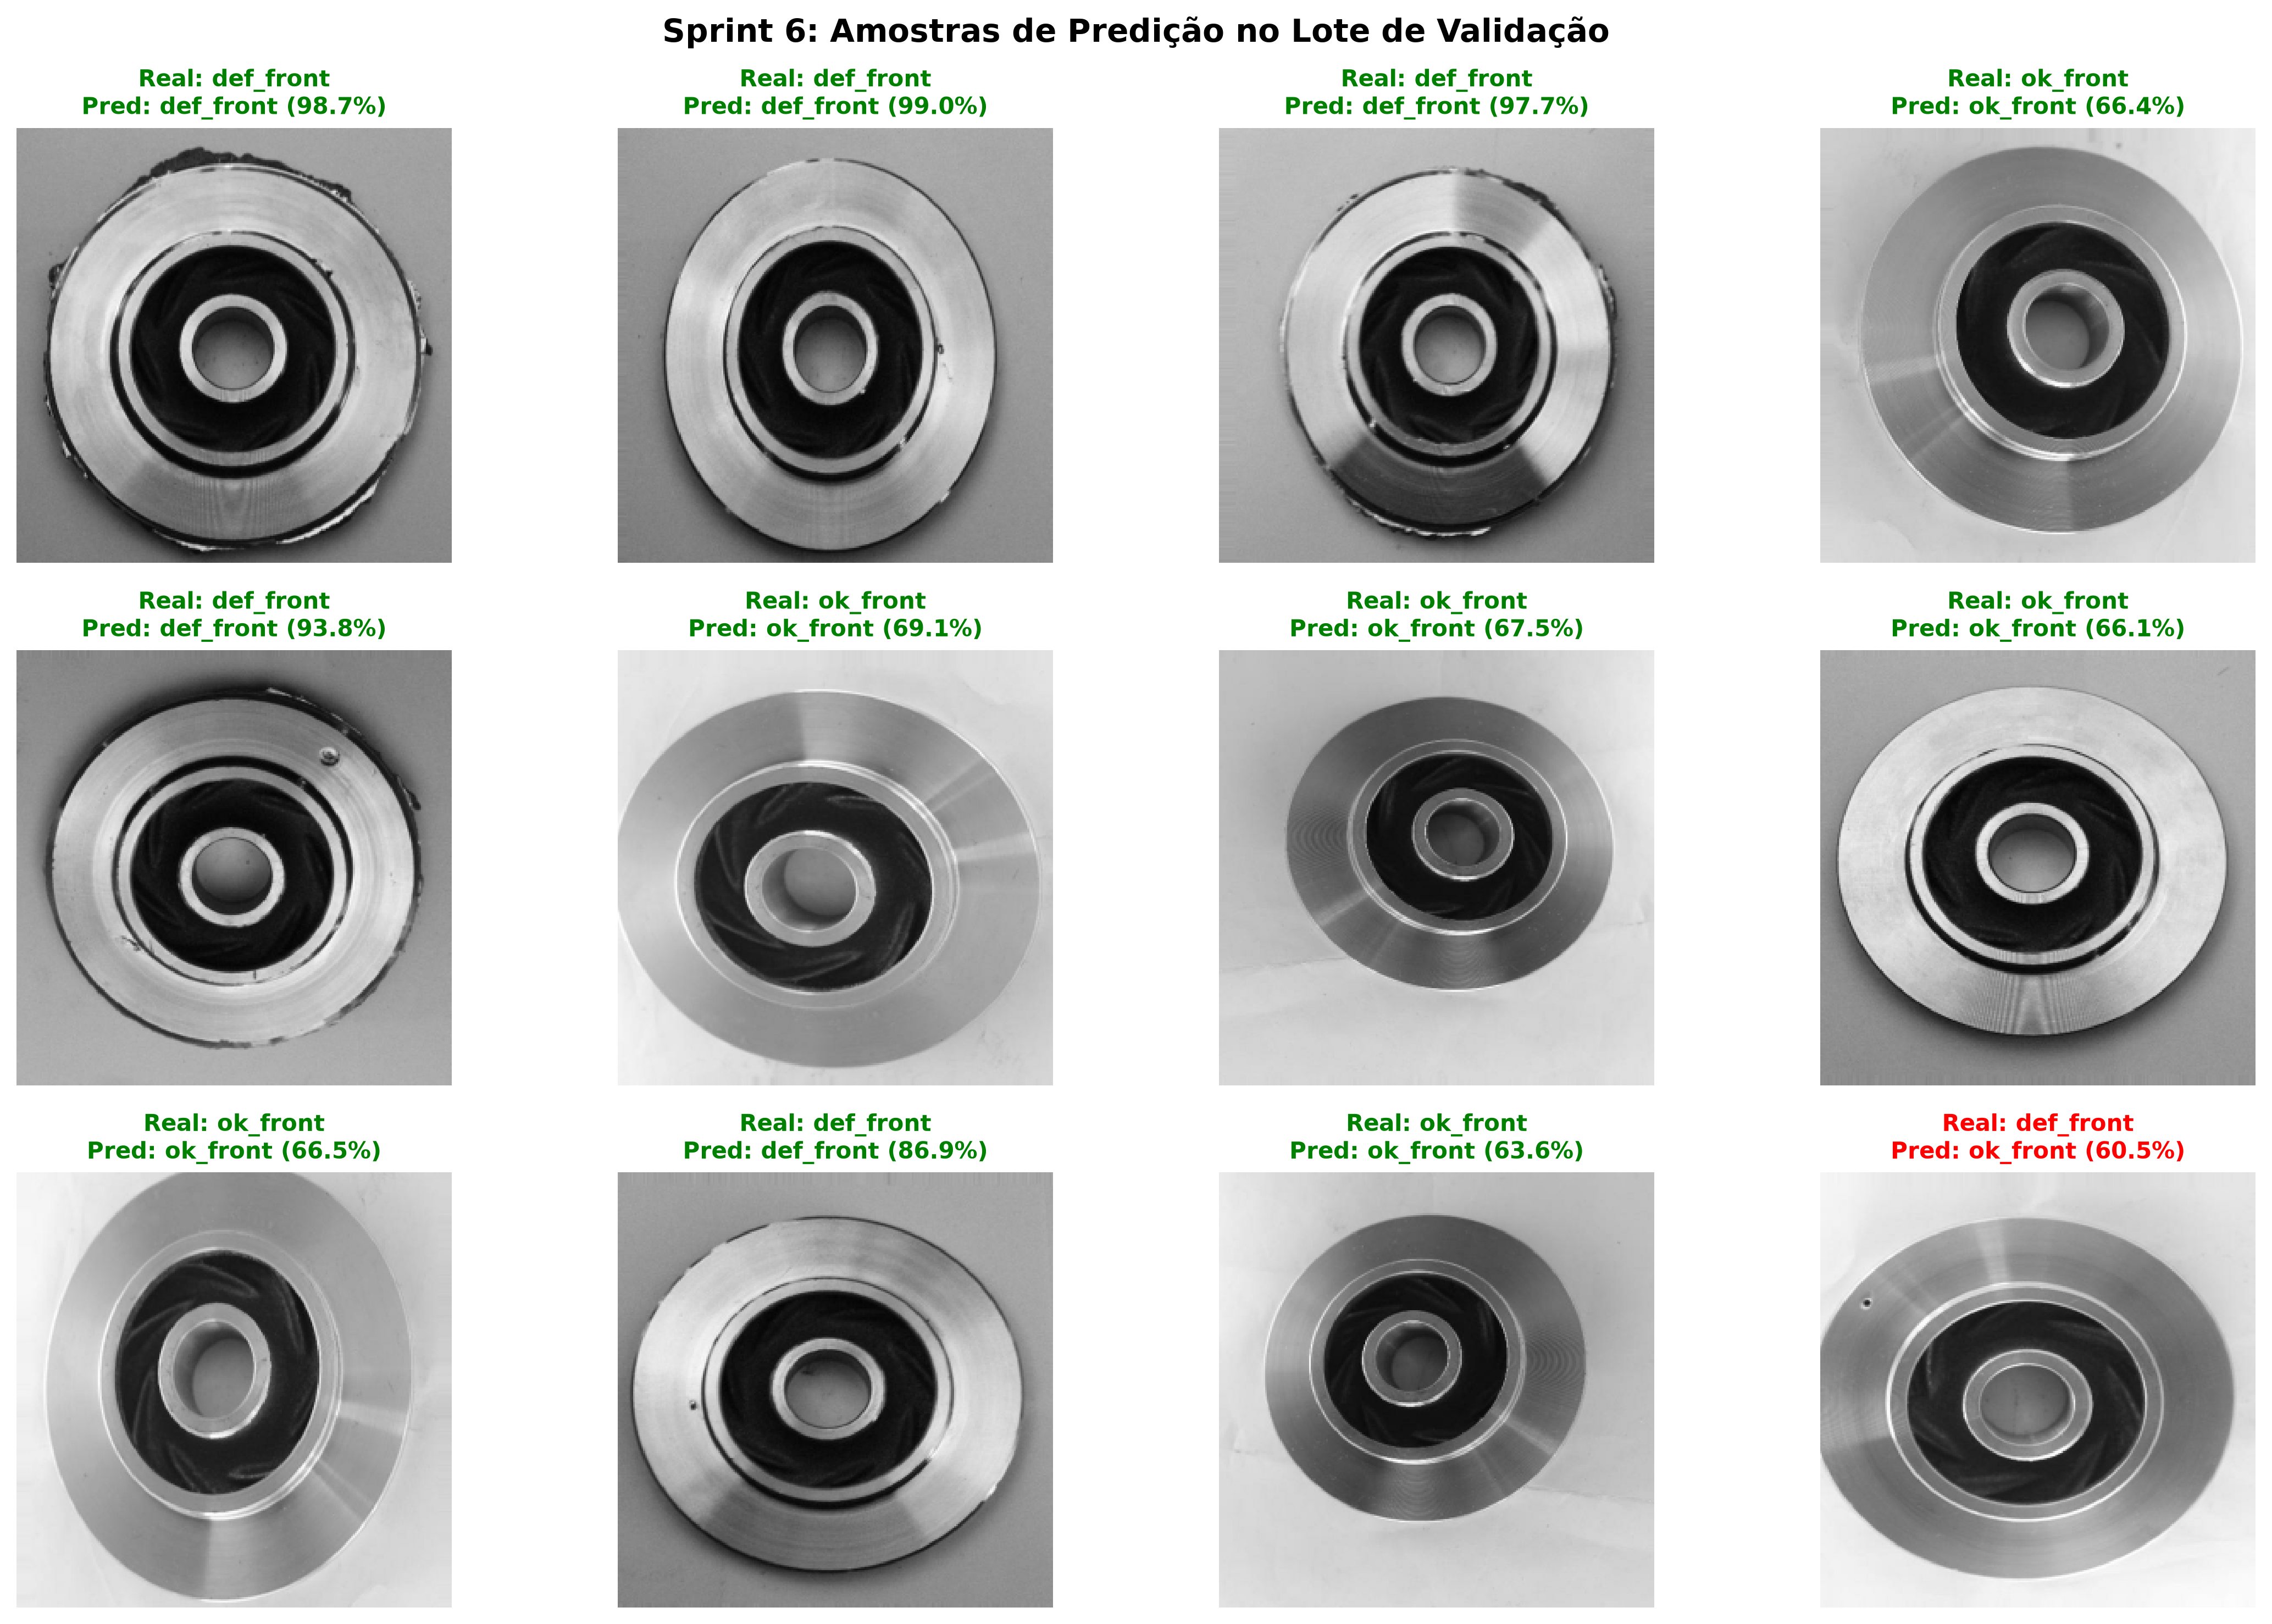

In [9]:
# Exibição dos Gráficos de Auditoria
from IPython.display import Image, display

print('--- Curvas Analíticas de Treinamento ---')
display(Image(filename='reports/figures/sprint6_loss_and_accuracy.png'))

print('--- Matriz de Confusão na Validação ---')
display(Image(filename='reports/figures/sprint6_confusion_matrix.png'))

print('--- Amostras de Predição Industrial ---')
display(Image(filename='reports/figures/sprint6_sample_predictions.png'))


---
## Diagnóstico Técnico de Aprendizado (Overfitting vs Aprendizado Saudável)
- **Comportamento da Curva de Perda (Loss):** 
  - A perda de treino declinou continuamente de ~0.68 para ~0.38.
  - A perda de validação (*val_loss*) acompanhou a trajetória descendente de forma harmoniosa, atingindo seu mínimo em ~0.34 na época 14.
- **Ausência de Overfitting:**
  - Em cenários com overfitting, observaríamos a perda de treino caindo enquanto a perda de validação subiria drasticamente (divergência). Aqui, ambas convergiram juntas, demonstrando que os mecanismos de regularização (**Data Augmentation** + **Dropout**) foram altamente eficazes.
- **Desempenho Geral:**
  - Acurácia global de **87%** na base de validação, com sensibilidade (*recall*) de 96% para peças normais e precisão de 97% na detecção de peças defeituosas.
